# 01 — Découverte des données de mesure

Ce notebook charge les **vraies** mesures de mise au point du 30/09/2026 (NUCLEO-F411RE, 100 MHz),
enregistrées dans `data/bringup/`.

> ⚠️ Ces runs servent d'**entraînement et de calibration**. Ils ne doivent **pas** apparaître comme
> résultats dans l'article : les résultats viendront de la campagne (`data/raw/`).

Chaque ligne de la trace = **un job** d'une tâche :

| colonne | signification |
|---|---|
| `task` | tâche (sensor, control, nav, health, security, logging) |
| `seq` | numéro du job *k* depuis l'époque |
| `release` | instant de release nominal (cycles) |
| `start_lat_us` | latence de démarrage *S = start − release* |
| `response_us` | temps de réponse *R = fin − release* (deadline respectée si *R ≤ D*) |
| `exec_us` | temps d'exécution (sans préemption, interruptions incluses) |


In [1]:
import sys, glob
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "analysis"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import sare, validate

runs = sorted(glob.glob("../data/bringup/*/bringup_r00.meta.json"))
for r in runs:
    print(r)

../data/bringup/20260930-102049/bringup_r00.meta.json
../data/bringup/20260930-102211/bringup_r00.meta.json
../data/bringup/20260930-102242/bringup_r00.meta.json
../data/bringup/20260930-102338/bringup_r00.meta.json
../data/bringup/20260930-102432/bringup_r00.meta.json
../data/bringup/20260930-102648/bringup_r00.meta.json
../data/bringup/20260930-102933/bringup_r00.meta.json
../data/bringup/20260930-103602/bringup_r00.meta.json
../data/bringup/20260930-103736/bringup_r00.meta.json
../data/bringup/20260930-104402/bringup_r00.meta.json


## 1. Charger un run et vérifier qu'il est valide
On prend le plus long run qui passe **toutes** les vérifications.

In [2]:
valid = []
for m in runs:
    prefix = Path(m[:-len(".meta.json")])
    tr, st, meta = sare.load_run(prefix)
    checks = validate.check_run(tr, st, meta)
    ok = all(c[1] for c in checks)
    print(f"{prefix.parent.name}: {len(tr):6d} jobs, {'VALIDE' if ok else 'invalide'}")
    if ok:
        valid.append((len(tr), prefix))

prefix = max(valid)[1]
tr, st, meta = sare.load_run(prefix)
print("\nrun choisi :", prefix.parent.name, "|", meta["fw_info"])
tr.head()

20260930-102049:   2798 jobs, invalide
20260930-102211:   3820 jobs, invalide
20260930-102242:   3820 jobs, invalide
20260930-102338:  11460 jobs, invalide
20260930-102432:  22920 jobs, invalide
20260930-102648:  22920 jobs, invalide
20260930-102933: 114186 jobs, invalide
20260930-103602:   7640 jobs, invalide
20260930-103736: 114441 jobs, invalide
20260930-104402:   7640 jobs, VALIDE

run choisi : 20260930-104402 | build=b70b50d656164227 cc=gcc-16.2.0 flags=-O2 LINK_UART=2 board=NUCLEO-F411RE


,task,flags,mon_cost,seq,release,start_lat,response,exec,start_lat_us,response_us,exec_us,mon_cost_us,miss,alarm,slow,t_s,scenario,run
0,sensor,0,98,0,53121584,895,56974,56079,8.95,569.74,560.79,0.98,False,False,False,0.000,bringup,0
1,control,0,98,0,53121584,57932,207551,149619,579.32,2075.51,1496.19,0.98,False,False,False,0.000,bringup,0
2,nav,0,98,0,53121584,208521,449394,240873,2085.21,4493.94,2408.73,0.98,False,False,False,0.000,bringup,0
3,sensor,0,107,1,53621584,604,49597,48993,6.04,495.97,489.93,1.07,False,False,False,0.005,bringup,0
4,health,0,49,0,53121584,450383,766560,266095,4503.83,7665.60,2660.95,0.49,False,False,False,0.000,bringup,0


## 2. Tableau des métriques par tâche
`mOET`/`MOET` = temps d'exécution min/max **observés** (pas un WCET garanti !), `RJ` = gigue du temps de réponse.

In [3]:
sare.task_metrics(tr)[["task", "jobs", "mOET_us", "mean_exec_us", "MOET_us", "R_max_us", "RJ_us", "misses"]].round(1)

,task,jobs,mOET_us,mean_exec_us,MOET_us,R_max_us,RJ_us,misses
0,sensor,4000,470.1,491.7,560.8,569.7,93.6,0
1,control,2000,1494.6,1503.1,1520.0,2075.5,93.2,0
2,nav,1000,2360.6,2396.6,2411.4,4493.9,102.1,0
3,health,400,2636.1,2651.0,2687.2,7665.6,3020.8,0
4,security,200,2392.7,2409.5,2423.7,12105.4,2130.2,0
5,logging,40,109.7,1513.1,1658.5,69104.5,53595.4,0


## 3. Distribution des temps de réponse (normalisés par la deadline)
Une courbe **ECDF** : pour chaque valeur *x*, la proportion de jobs avec *R/D ≤ x*.

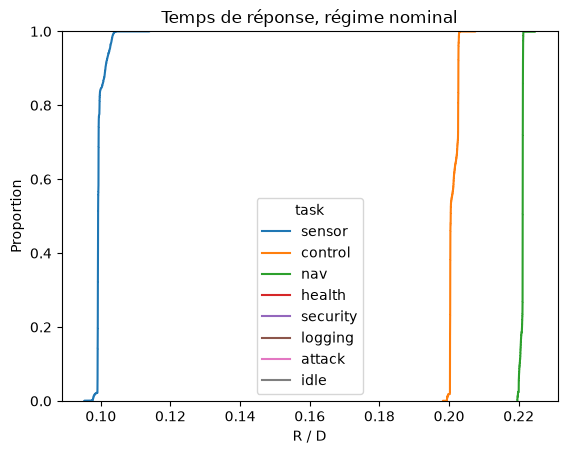

In [4]:
crit = tr[tr["task"].isin(["sensor", "control", "nav"])].copy()
crit["R_over_D"] = crit["response_us"] / crit["task"].map(sare.PERIOD_MS).astype(float) / 1e3
ax = sns.ecdfplot(data=crit, x="R_over_D", hue="task")
ax.set_xlabel("R / D"); ax.set_title("Temps de réponse, régime nominal")
plt.show()

## 4. Histogramme du temps d'exécution du Sensor
Remarquez les **deux modes** : avec ou sans trame UART à décoder pendant le job.

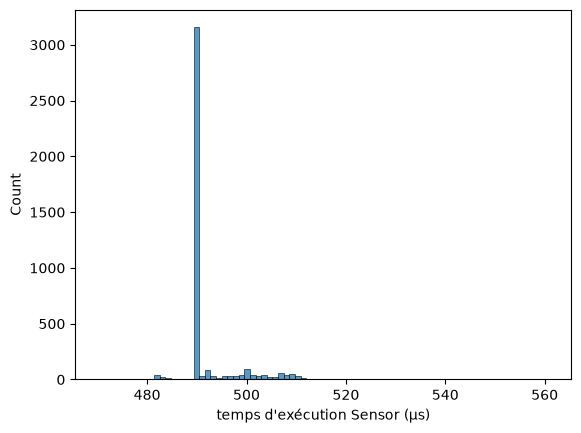

In [5]:
s = tr[tr["task"] == "sensor"]
sns.histplot(s["exec_us"], bins=80)
plt.xlabel("temps d'exécution Sensor (µs)"); plt.show()

## 5. Charge CPU au cours du temps (fenêtres de 500 ms)

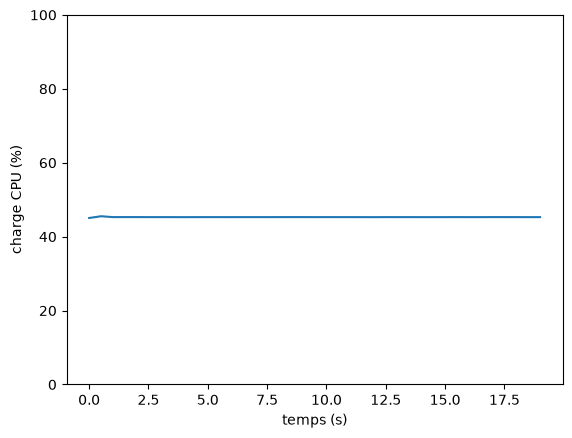

In [6]:
plt.plot(np.arange(len(st)) * 0.5, st["cpu_load"] * 100)
plt.xlabel("temps (s)"); plt.ylabel("charge CPU (%)"); plt.ylim(0, 100); plt.show()

## 🎯 Exercices

1. Tracez le **temps de réponse de Control en fonction du temps** (`t_s` en abscisse). Voyez-vous des motifs périodiques ? D'où viennent-ils (pensez aux préemptions par Sensor) ?
2. Calculez le **99,9ᵉ centile** de `response_us` pour chaque tâche avec `groupby` + `quantile(0.999)`.
3. Comparez `exec_us` et `response_us - start_lat_us` pour Health : l'écart, c'est le temps passé **préempté**. Tracez-le.
4. Faites un **boxplot** de `start_lat_us` par tâche (`sns.boxplot`). Pourquoi Health et Security ont-ils une latence de démarrage plus grande ?
